# 02a — Column generation, walked through (replay)

This notebook reconstructs the column-generation demo from the slides
deck (`RF-branching/slides/qcg_vs_cg_demo/`) using bundled per-PSP JSON
artifacts. **No API access required** — every Dirac response and every
LP column was recorded once and saved to disk.

We'll see:

1. The CG **set-cover LP** for vertex coloring and how the dual
   variables become the per-vertex weights for the pricing subproblem.
2. **PSP #1** (uniform duals, first CG iteration) — Dirac extracts 4
   columns; classical LP extracts 16 smaller ones.
3. **PSP #2** (later iteration, differentiated duals) — extraction
   patterns diverge.
4. Aggregate stats (count, size, dual-sum coverage).

For a *live* version where you supply your own graph, see `02b`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import _demo_utils as U
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## 1. The set-cover LP for vertex coloring

For a graph $G$ let $\mathcal{S}$ denote the set of *independent sets*
in $G$. Vertex coloring with as few colors as possible is

$$\min \sum_{S \in \mathcal{S}} x_S \;\text{ s.t. }\; \sum_{S \ni v} x_S \ge 1 \;\forall v,\; x_S \in \{0,1\}.$$

Relaxing $x_S \in [0,1]$ gives the **restricted master problem (RMP)**,
solved by `scipy.linprog`. The dual variables $y_v$ price each vertex.
The **pricing subproblem** asks for an independent set $S$ with
$\sum_{v\in S} y_v > 1$ (a *profitable column*); if none exists, the
LP is optimal. That's where Dirac comes in — it's a max-weight
independent-set sampler.

## 2. PSP #1 — early CG iteration, uniform duals

Initial coloring is the trivial one (each vertex its own color), so the
RMP starts with $y_v = 1$ for every $v$ — you can think of the
pricing subproblem here as plain (unweighted) MIS.

In [2]:
psp1 = U.load_psp(1)
G = U.psp_to_graph(psp1)
layout = U.psp_to_layout(psp1)
duals1 = U.psp_dual_array(psp1)

print(f"Instance: {psp1['instance_id']}  n={psp1['n']}  m={psp1['m']}")
print(f"PSP label: {psp1['psp_label']}")
print(f"dual sum: {duals1.sum():.1f}  (uniform = n)")


Instance: er_n20_p70_s0  n=20  m=131
PSP label: PSP #1: first CG iter (uniform duals)
dual sum: 20.0  (uniform = n)


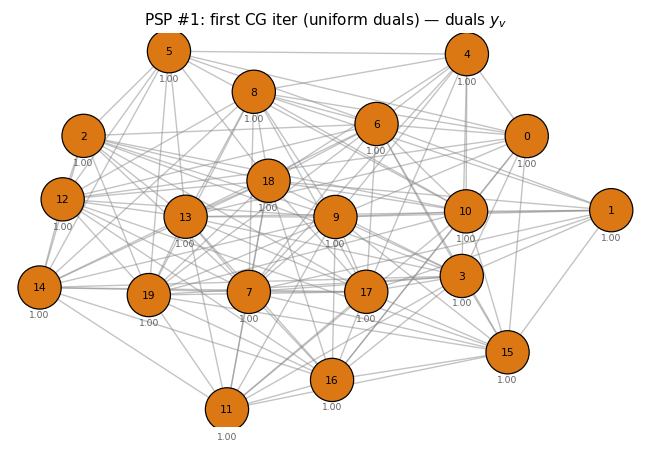

In [3]:
# Visualise the dual weights on the graph
fig, ax = U.draw_graph_duals(G, duals1, layout,
                             title=f"{psp1['psp_label']} — duals $y_v$")
plt.show()


Dirac extracted 4 columns; LP extracted 16.


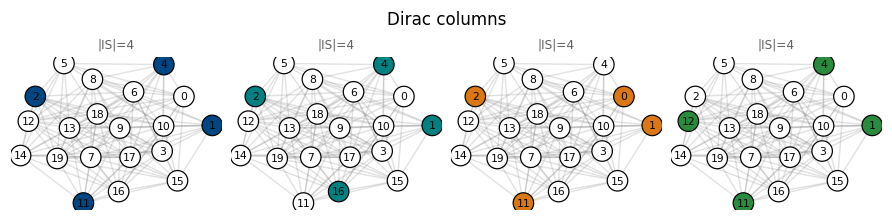

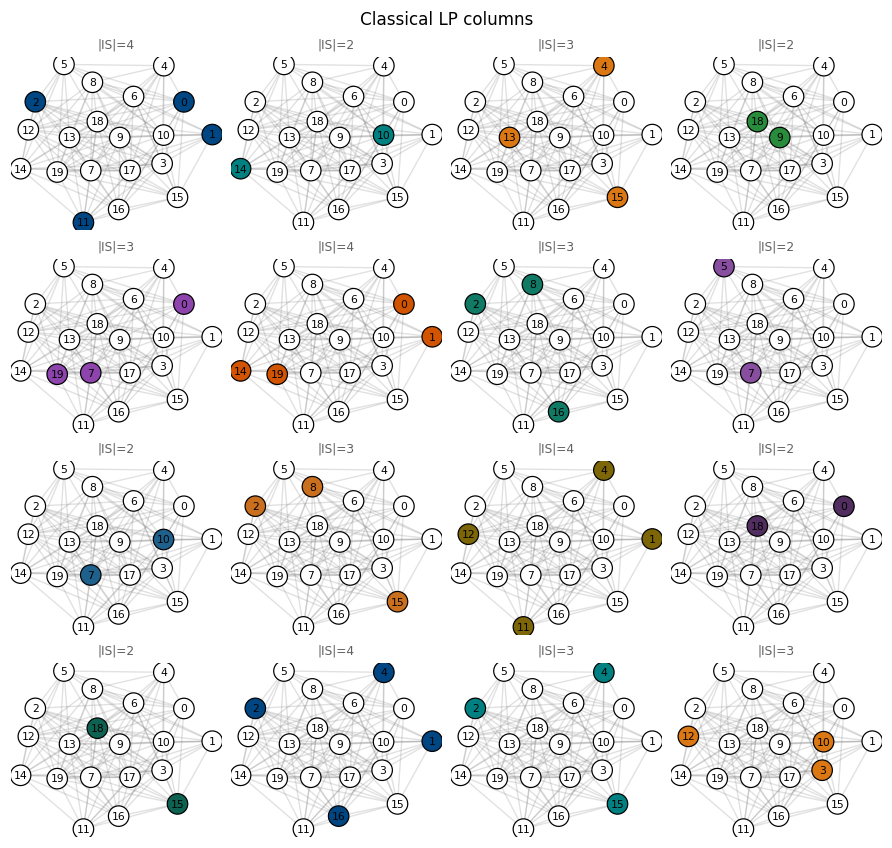

In [4]:
# Side-by-side: Dirac columns vs LP columns
dirac_cols = [list(c) for c in psp1["dirac"]["columns"]]
lp_cols    = [list(c) for c in psp1["classical"]["columns"]]

print(f"Dirac extracted {len(dirac_cols)} columns; LP extracted {len(lp_cols)}.")
fig1, _ = U.draw_columns_grid(G, dirac_cols, layout, ncols=4,
                              suptitle="Dirac columns")
fig2, _ = U.draw_columns_grid(G, lp_cols, layout, ncols=4,
                              suptitle="Classical LP columns")
plt.show()


In [5]:
# Stats table
def stats_row(side, source):
    s = source["columns_stats"]
    return {"side": side, "count": s["count"], "avg_size": s["avg_size"],
            "max_size": s["max_size"], "avg_dual_sum": np.mean(s["dual_sums"]),
            "max_dual_sum": max(s["dual_sums"])}

rows = [stats_row("Dirac", psp1["dirac"]),
        stats_row("LP",    psp1["classical"])]
pd.DataFrame(rows)


,side,count,avg_size,max_size,avg_dual_sum,max_dual_sum
0,Dirac,4,4.000,4,4.000,4.0
1,LP,16,2.875,4,2.875,4.0


**`★` Insight.** Notice both sides have the *same* total dual-sum
coverage: each column contributes $\sum_{v\in S} y_v = |S|$ since duals
are uniform = 1. Dirac picks **fewer, larger** independent sets;
classical LP fan-out finds **many smaller** sets. Both are profitable
(dual sum $\ge 2 > 1$). Larger columns generally remove more of the
LP's slack, but more columns enrich the basis.

## 3. PSP #2 — differentiated duals

After several CG iterations the RMP has many columns and the dual
weights become non-uniform. Vertices that are "harder to cover"
(participate in fewer favorable cliques) get higher weights, and Dirac
chases support concentrated on those vertices.

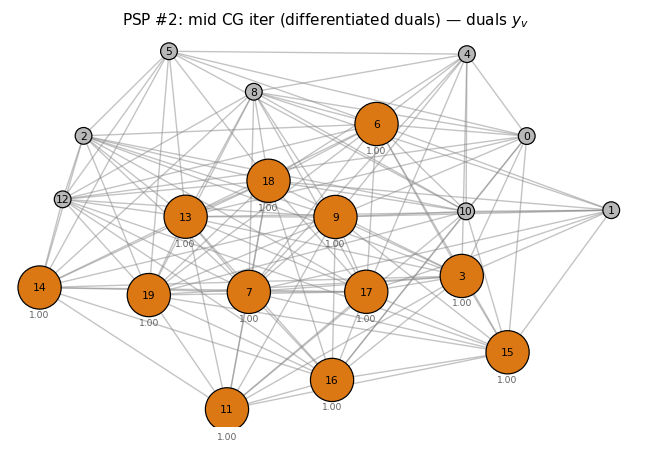

PSP2 dual values (top 5): [1.0, 1.0, 1.0, 1.0, 1.0] ... min=1.00


In [6]:
psp2 = U.load_psp(2)
duals2 = U.psp_dual_array(psp2)

fig, ax = U.draw_graph_duals(G, duals2, layout,
                             title=f"{psp2['psp_label']} — duals $y_v$")
plt.show()
print(f"PSP2 dual values (top 5): "
      f"{sorted(duals2, reverse=True)[:5]} ... min={duals2[duals2>0].min():.2f}")


Dirac extracted 6 columns; LP extracted 7.


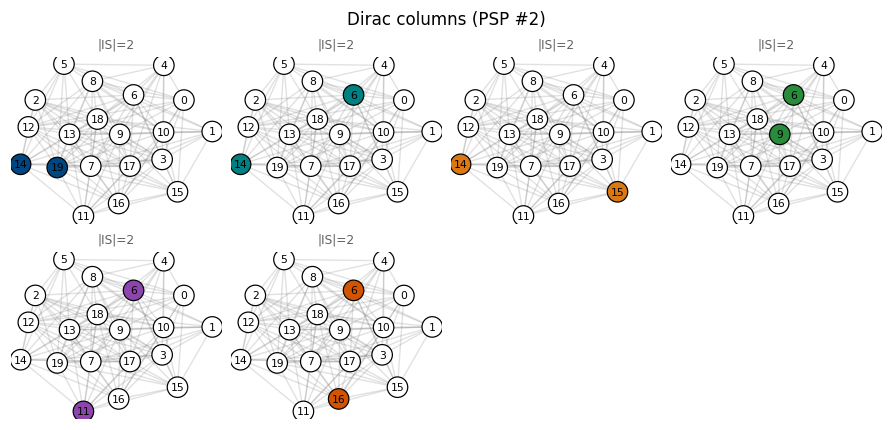

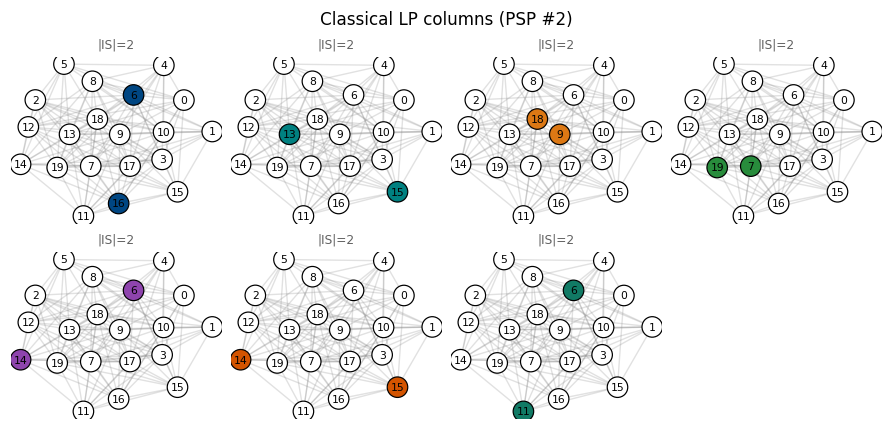

,side,count,avg_size,max_size,avg_dual_sum,max_dual_sum
0,Dirac,6,2.0,2,2.0,2.0
1,LP,7,2.0,2,2.0,2.0


In [7]:
dirac_cols2 = [list(c) for c in psp2["dirac"]["columns"]]
lp_cols2    = [list(c) for c in psp2["classical"]["columns"]]

print(f"Dirac extracted {len(dirac_cols2)} columns; LP extracted {len(lp_cols2)}.")
fig1, _ = U.draw_columns_grid(G, dirac_cols2, layout, ncols=4,
                              suptitle="Dirac columns (PSP #2)")
fig2, _ = U.draw_columns_grid(G, lp_cols2, layout, ncols=4,
                              suptitle="Classical LP columns (PSP #2)")
plt.show()

pd.DataFrame([stats_row("Dirac", psp2["dirac"]),
              stats_row("LP",    psp2["classical"])])


## 4. Aggregate — columns per call across both PSPs

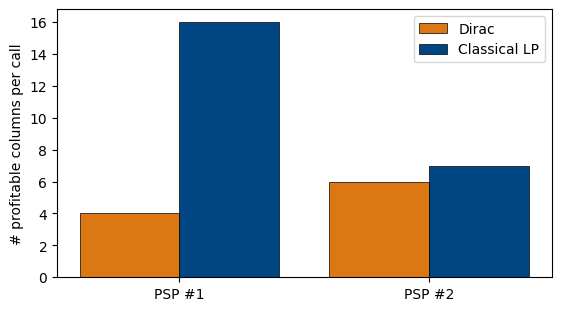

In [8]:
# Bar chart
fig, ax = plt.subplots(figsize=(5.5, 3.0), constrained_layout=True)
psps = ["PSP #1", "PSP #2"]
dirac_counts = [psp1["dirac"]["columns_stats"]["count"],
                psp2["dirac"]["columns_stats"]["count"]]
lp_counts    = [psp1["classical"]["columns_stats"]["count"],
                psp2["classical"]["columns_stats"]["count"]]
x = np.arange(len(psps))
ax.bar(x - 0.2, dirac_counts, 0.4, label="Dirac",      color=U.QCI_ORANGE,
       edgecolor="black", linewidth=0.5)
ax.bar(x + 0.2, lp_counts,    0.4, label="Classical LP", color=U.QCI_BLUE,
       edgecolor="black", linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(psps)
ax.set_ylabel("# profitable columns per call")
ax.legend()
plt.show()


## 5. Where to next?

* `02b` — same walkthrough but on **your own graph**, with a real Dirac
  call (cloud or direct). Saves the raw responses locally so you can
  replay later.
* `03a` / `03b` — full pipeline comparison vs greedy / HiGHS / Hexaly /
  classical B&P.